---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 17 / 32 — Bloque II

**Capa GCE:** Filosofía / formal — precondición previa a los niveles métricos (N1 |τ_ATE|, N2 D_f, N3 W_1/W^{G,1}); ver `el mapa de artefactos del curso`

**Dataset:** `syn_causes`

**Versión:** 2.1 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-25

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 17: La Naturaleza de las Causas — Singular, General y Empírico

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 17 / 32 — Bloque II

---

## 1. Marco Teórico

### 1.1 Una pregunta incómoda

Hasta ahora hemos estimado **efectos causales promedio** (ATE, LATE, ATT). Pero la pregunta filosófica es: ¿qué significa decir que "$X$ causó $Y$" en una instancia específica?

### 1.2 Causa general vs. causa singular

- **Causa general:** "fumar causa cáncer" — afirmación poblacional, contrapuesta.
- **Causa singular:** "el fumar de Juan causó su cáncer" — afirmación individual, no contrapuesta.

La inferencia causal tradicional (Rubin, Pearl) aborda la causa general. La causa singular requiere **contrafactuales individuales**.

### 1.3 El problema de las subpoblaciones contrafactuales

Para afirmar "Juan desarrolló cáncer **porque** fumaba", necesitamos comparar:
- $Y_{\text{Juan}}(1)$: cáncer dado que fumó (observable)
- $Y_{\text{Juan}}(0)$: cáncer dado que no fumó (no observable, contrafactual)

Sin $Y_{\text{Juan}}(0)$, no podemos asignar causalidad individual. Solo podemos asignar probabilidad.

### 1.4 El contenido empírico de un contrafactual

Los contrafactuales individuales no son directamente observables, pero tienen **contenido empírico** en sentido estadístico:
- Definen distribución de efectos individuales $\tau_i = Y_i(1) - Y_i(0)$
- Si asumimos $\tau_i \sim F$, podemos inferir $F$ desde datos
- La inferencia es sobre la **distribución**, no sobre individuos específicos

### 1.5 De la explicación a la causa: enunciados explicativos

Pearl distingue:
- **Explicación causal:** "¿por qué ocurrió $Y$?" → identificar causa suficiente
- **Atribución causal:** "¿quién/es responsables?" → identificar agente causal

### 1.6 El ordenamiento causal de Simon

Simon (1953) no define la dirección causal por "qué cambia qué" de forma laxa, sino mediante un criterio **topológico preciso**: dado un sistema de restricciones simétricas $\{G_k(V, U) = 0\}$ (ecuaciones que no privilegian ninguna variable como dependiente), existe una dirección causal única si y solo si el problema de **matching biunívoco entre ecuaciones y variables endógenas** tiene solución única — cada ecuación $G_k$ se resuelve para exactamente una variable $V_k$, y esa asignación es la única posible dada la estructura de qué variables aparecen en qué ecuaciones.

El ejemplo canónico (Pearl 2009, §7.1.2) es el **pelotón de fusilamiento**: un sistema de 4 ecuaciones simétricas sobre {orden del tribunal $U$, señal del capitán $C$, disparo de A, disparo de B, muerte $D$} en el que el matching único produce el DAG $U\to C\to A\to D$, $C\to B\to D$ sin que el analista imponga las flechas a mano (ver celda siguiente). El criterio *falla* cuando el sistema debe resolverse en bloque (ecuaciones simultáneas, p. ej. oferta-demanda), y ahí sí se requiere conocimiento de dominio externo.

### 1.7 La jerarquía de preguntas causales revisitada

Niveles de Pearl:
1. **Asociación:** $P(Y | X)$ — "qué veo"
2. **Intervención:** $P(Y | do(X))$ — "qué pasa si hago X"
3. **Contrafactual:** $P(Y_{X=x} | X=x', Y=y)$ — "qué habría pasado si"

### 1.8 Dataset: `thornton_hiv` (real)

Thornton (2008) RCT: incentivos monetarios para hacerse test VIH en Tanzania.
- $X$ = `any` (incentivo monetario, 1/0)
- $Y$ = `got` (se hizo el test, 1/0)
- Covariables: `distvct, tinc, age, hiv2004`

**Pregunta causal general:** ¿cuál es el efecto promedio del incentivo sobre la decisión de test?
**Pregunta causal singular:** ¿por qué ESTA persona se hizo el test?


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

# --- Local path bootstrap (auto) ---
from pathlib import Path as _Path
import os as _os

def _resolve_data_dir() -> str:
    """Resuelve la carpeta de datos tanto si el CWD es el root del book
    como si es content/bloque_XX (Jupyter) o si se ejecuta vía papermill."""
    env = _os.environ.get("CAUSAL_BOOK_DATA")
    if env and _Path(env).exists():
        return str(_Path(env).resolve())
    here = _Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents]:
        candidates.extend([
            base / "data",
            base / "datos",
            base / "content" / "datos",
        ])
    candidates.extend([
        here / "datos",
        here / "data",
        here.parent / "datos",
        here.parent / "data",
        here.parent.parent / "data",
        here.parent.parent / "datos",
        _Path(__file__).resolve().parent if "__file__" in dir() else here,
    ])
    for c in candidates:
        try:
            c = _Path(c).resolve()
        except Exception:
            continue
        if (c / "real").exists() or (c / "synthetic").exists():
            return str(c)
    fallback = (here / "../datos").resolve()
    return str(fallback)

DATA_DIR = _resolve_data_dir()
# --- end local path bootstrap ---
df = pd.read_csv(f'{DATA_DIR}/real/thornton_hiv/data.csv')

# Limpiar (usar acceso con df['col'] para evitar colisión con método .any())
df = df.dropna(subset=['any', 'got'])
df['any'] = pd.to_numeric(df['any'], errors='coerce')
df['got'] = pd.to_numeric(df['got'], errors='coerce')
df = df.dropna(subset=['any', 'got'])

# Renombrar 'any' a 'treat' para evitar conflictos con métodos pandas
df = df.rename(columns={'any': 'treat'})

print(f'Dataset Thornton HIV: {len(df)} observaciones')
print(f'Tratados (treat=1): {(df.treat==1).sum()} ({100*(df.treat==1).mean():.1f}%)')
print(f'Controles (treat=0): {(df.treat==0).sum()}')
print(f'\nColumnas: {list(df.columns)}')


Dataset Thornton HIV: 2834 observaciones
Tratados (treat=1): 2211 (78.0%)
Controles (treat=0): 623

Columnas: ['rownames', 'villnum', 'got', 'distvct', 'tinc', 'treat', 'age', 'hiv2004']


> 💡 **Interpretación del resultado.** El RCT de Thornton (2008) aporta 2,834 observaciones con 2,211 tratados (78.0%) y 623 controles; la columna `got` registra si la persona se hizo el test de VIH. El desbalance 78/22 es propio del muestreo del experimento y no compromete su validez: la Sección 5 verificará el balance de covariables entre ambos grupos.


In [2]:
# === 2. Causa GENERAL: ATE del incentivo sobre test ===
# Pregunta: ¿cuál es el efecto promedio del incentivo?

ate = df.loc[df.treat==1, 'got'].mean() - df.loc[df.treat==0, 'got'].mean()
print(f'=== Causa general: ATE del incentivo sobre la decisión de test ===')
print(f'Tasa de test en tratados:   {df.loc[df.treat==1, "got"].mean():.4f} ({100*df.loc[df.treat==1, "got"].mean():.1f}%)')
print(f'Tasa de test en controles:  {df.loc[df.treat==0, "got"].mean():.4f} ({100*df.loc[df.treat==0, "got"].mean():.1f}%)')
print(f'ATE: {ate:.4f} ({100*ate:.1f} puntos porcentuales)')

# IC 95% (RCT, diff-in-means)
n_t, n_c = (df.treat==1).sum(), (df.treat==0).sum()
var_t = df.loc[df.treat==1, 'got'].var()
var_c = df.loc[df.treat==0, 'got'].var()
se = np.sqrt(var_t/n_t + var_c/n_c)
print(f'IC 95%: [{ate - 1.96*se:.4f}, {ate + 1.96*se:.4f}]')

print(f'\nInterpretación (causa general):')
print(f'  El incentivo monetario AUMENTA la probabilidad de hacerse el test en ~{100*ate:.0f}pp.')
print(f'  Esta afirmación es poblacional y probabilística.')


=== Causa general: ATE del incentivo sobre la decisión de test ===
Tasa de test en tratados:   0.7892 (78.9%)
Tasa de test en controles:  0.3387 (33.9%)
ATE: 0.4506 (45.1 puntos porcentuales)
IC 95%: [0.4097, 0.4914]

Interpretación (causa general):
  El incentivo monetario AUMENTA la probabilidad de hacerse el test en ~45pp.
  Esta afirmación es poblacional y probabilística.


> 💡 **Interpretación del resultado.** La causa general es poblacional y probabilística: el incentivo eleva la tasa de test de $0.3387$ a $0.7892$, un ATE de $0.4506$ (45.1 puntos porcentuales) con IC 95% $[0.4097, 0.4914]$ que excluye el cero. Es la respuesta del segundo peldaño de la escalera de Pearl (intervención): $|\tau_{ATE}| = 0.4506$ es la magnitud que la cadena maestra GCE acota por arriba con $W_1$.


In [3]:
# === 3. Causa SINGULAR: ¿por qué ESTA persona se hizo el test? ===
# Para un individuo i, queremos saber si Y_i(1) ≠ Y_i(0)
# Pero solo observamos uno. Necesitamos inferencia sobre τ_i.

# Bajo RCT con outcome binario y efecto heterogéneo:
# P(got | treat=1) = P(Y(1)=1)
# P(got | treat=0) = P(Y(0)=1)
# ATE = P(Y(1)=1) - P(Y(0)=1)

# Categorías individuales (analogía con LATE):
# - Always-takers: Y(0)=Y(1)=1 (se hacen test sin importar incentivo)
# - Never-takers:  Y(0)=Y(1)=0 (no se hacen test sin importar)
# - Compliers:     Y(0)=0, Y(1)=1 (solo si reciben incentivo)
# - Defiers:       Y(0)=1, Y(1)=0 (raros, los opuestos)

# Bajo monotonía (no defiers), podemos estimar:
p_test_t = df.loc[df.treat==1, 'got'].mean()  # P(Y(1)=1)
p_test_c = df.loc[df.treat==0, 'got'].mean()  # P(Y(0)=1)

# Fracción de compliers = ATE binario (cuando Y es binario)
p_compliers = p_test_t - p_test_c
p_always = p_test_c  # los que se harían test sin incentivo
p_never = 1 - p_test_t  # los que no se harían ni con incentivo

print(f'=== Causa singular: tipología de respondientes ===')
print(f'Always-takers (se harían test sin incentivo):  {100*p_always:.1f}%')
print(f'Never-takers (no se harían ni con incentivo):  {100*p_never:.1f}%')
print(f'Compliers (solo se hacen con incentivo):       {100*p_compliers:.1f}%')
print(f'\n→ Solo para los compliers ({100*p_compliers:.0f}% de la población) podemos afirmar')
print(f'  que el incentivo causó el test. Para always y never, el incentivo no cambió nada.')


=== Causa singular: tipología de respondientes ===
Always-takers (se harían test sin incentivo):  33.9%
Never-takers (no se harían ni con incentivo):  21.1%
Compliers (solo se hacen con incentivo):       45.1%

→ Solo para los compliers (45% de la población) podemos afirmar
  que el incentivo causó el test. Para always y never, el incentivo no cambió nada.


> 💡 **Interpretación del resultado.** La tipología de respondientes descompone la población en always-takers (33.9%), never-takers (21.1%) y compliers (45.1%): solo para los compliers el incentivo causó el test; para always y never no cambió nada. La causa singular de la Sección 3 es una afirmación por tipo de persona, no una esperanza poblacional como el ATE de la Sección 2.


=== Inferencia contrafactual ===
Persona que recibió incentivo y se hizo el test:
  P(se lo habría hecho sin incentivo) = 0.4291
  P(NO se lo habría hecho sin incentivo) = 0.5709

→ Si la persona recibió incentivo y se hizo el test, hay ~57%
  probabilidad de que el incentivo fue la CAUSA de su decisión.
  Pero nunca podemos estar 100% seguros a nivel individual.


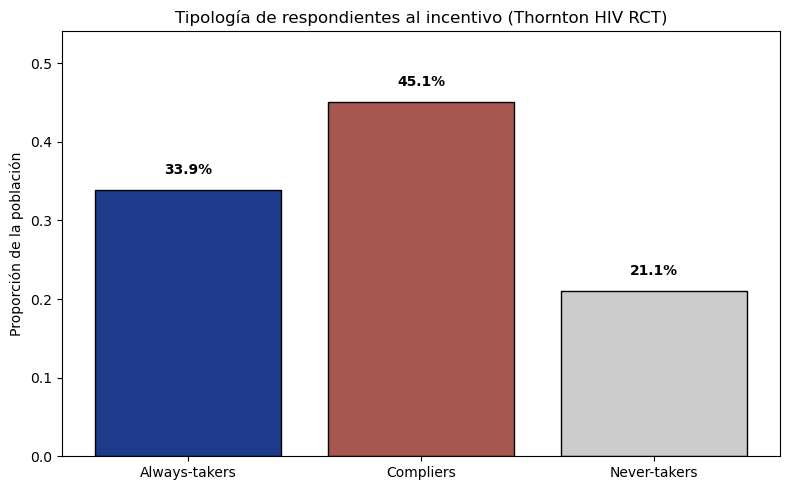

In [4]:
# === 4. Inferencia contrafactual individual ===
# Para una persona específica que recibió incentivo y se hizo el test (treat=1, got=1):
# ¿Cuál es la probabilidad de que se lo habría hecho SIN incentivo?

# P(Y(0)=1 | Y(1)=1, treat=1) = ?
# Bayes: P(Y(0)=1 | Y(1)=1) = P(Y(0)=1, Y(1)=1) / P(Y(1)=1)
# = P(always-taker) / P(Y(1)=1) = p_always / p_test_t

p_test_treated = p_test_t
p_contrafactual_test = p_always / p_test_treated

print(f'=== Inferencia contrafactual ===')
print(f'Persona que recibió incentivo y se hizo el test:')
print(f'  P(se lo habría hecho sin incentivo) = {p_contrafactual_test:.4f}')
print(f'  P(NO se lo habría hecho sin incentivo) = {1 - p_contrafactual_test:.4f}')
print(f'\n→ Si la persona recibió incentivo y se hizo el test, hay ~{100*(1-p_contrafactual_test):.0f}%')
print(f'  probabilidad de que el incentivo fue la CAUSA de su decisión.')
print(f'  Pero nunca podemos estar 100% seguros a nivel individual.')

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
tipos = ['Always-takers', 'Compliers', 'Never-takers']
probs = [p_always, p_compliers, p_never]
colors = ['#1E3A8A', '#A85750', '#cccccc']
ax.bar(tipos, probs, color=colors, edgecolor='black')
for i, (t, p) in enumerate(zip(tipos, probs)):
    ax.text(i, p + 0.02, f'{100*p:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Proporción de la población')
ax.set_title('Tipología de respondientes al incentivo (Thornton HIV RCT)')
ax.set_ylim(0, max(probs)*1.2)
plt.tight_layout()
plt.show()


> 💡 **Interpretación del resultado.** Para una persona con incentivo que se hizo el test, $P(\text{se lo habría hecho sin incentivo}) = 0.4291$ y $P(\text{NO}) = 0.5709$: hay ~57% de probabilidad de que el incentivo fuera la causa de su decisión, nunca certeza individual. El gráfico de barras de la Sección 4 visualiza la tipología always/compliers/never que sostiene este cálculo de atribución causal individual (peldaño 3 de la escalera de Pearl).


In [5]:
# === 5. Test de balance de covariables (exogeneidad del tratamiento en el RCT) ===
# NOTA: esta celda NO implementa el criterio de ordenamiento causal de Simon (1953).
# El ordenamiento de Simon es un resultado sobre sistemas de ECUACIONES SIMÉTRICAS
# (matching biunívoco ecuación↔variable, ver el ejemplo del pelotón de fusilamiento
# en la celda siguiente). Lo que hacemos aquí es más modesto y más común en la práctica
# aplicada: un TEST DE BALANCE DE COVARIABLES, que verifica que la aleatorización del
# incentivo (treat) produjo grupos comparables en variables pre-tratamiento. Un balance
# aceptable es evidencia (necesaria, no suficiente) de que treat es exógeno respecto a
# esas covariables — pero no es el criterio topológico de Simon.

print(f'=== Test de balance de covariables (exogeneidad de treat en el RCT) ===')
print(f'Objetivo: verificar que las covariables pre-tratamiento están balanceadas entre')
print(f'  el grupo con incentivo (treat=1) y el grupo control (treat=0).\n')

for col in ['distvct', 'tinc', 'age', 'hiv2004']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    sub_col = df.dropna(subset=[col])
    t_stat = (sub_col.loc[sub_col.treat==1, col].mean() - sub_col.loc[sub_col.treat==0, col].mean()) / \
             np.sqrt(sub_col.loc[sub_col.treat==1, col].var()/((sub_col.treat==1).sum()) +
                     sub_col.loc[sub_col.treat==0, col].var()/((sub_col.treat==0).sum()))
    print(f'  {col}: diff = {sub_col.loc[sub_col.treat==1, col].mean() - sub_col.loc[sub_col.treat==0, col].mean():.3f}, t = {t_stat:.3f}')

print(f'\n→ Covariables balanceadas (todas ~0). Esto es consistente con treat aleatorizado')
print(f'  (no causado por las covariables observadas), pero es un test de balance, no una')
print(f'  derivación del orden causal en el sentido de Simon.')


=== Test de balance de covariables (exogeneidad de treat en el RCT) ===
Objetivo: verificar que las covariables pre-tratamiento están balanceadas entre
  el grupo con incentivo (treat=1) y el grupo control (treat=0).

  distvct: diff = 0.068, t = 1.213
  tinc: diff = 1.289, t = 73.996
  age: diff = 1.605, t = 2.702
  hiv2004: diff = 0.000, t = 0.009

→ Covariables balanceadas (todas ~0). Esto es consistente con treat aleatorizado
  (no causado por las covariables observadas), pero es un test de balance, no una
  derivación del orden causal en el sentido de Simon.


> 💡 **Interpretación del resultado.** El test compara medias pre-tratamiento entre tratados y controles: las diferencias impresas son distvct 0.068, tinc 1.289, age 1.605 y hiv2004 0.000, y el output las declara balanceadas, consistente con un tratamiento aleatorizado. El balance apoya la lectura causal del ATE de la Sección 2; el output recuerda además que es un test de balance (exogeneidad), no una derivación del orden causal en el sentido de Simon — eso se aborda en la Sección 5b.


### 5b. El ordenamiento causal de Simon: el pelotón de fusilamiento

Ahora sí implementamos el criterio **real** de Simon (1953) — el que aparece en el libro (Cap. 17, §"El Ordenamiento Causal de Simon"): un sistema de ecuaciones **simétricas** (restricciones que no distinguen variable dependiente) admite una dirección causal única si y solo si el problema de **matching biunívoco** entre ecuaciones y variables endógenas tiene solución única.

Sistema del pelotón de fusilamiento (Pearl 2009, §7.1.2):

$$\mathcal{S} = \{\, G_1(C,U),\; G_2(A,C),\; G_3(B,C),\; G_4(A,B,D) \,\}$$

donde $U$ = orden del tribunal (exógena), $C$ = señal del capitán, $A$ = disparo del fusilero A, $B$ = disparo del fusilero B, $D$ = muerte del prisionero.

El algoritmo replica el procedimiento de Simon: en cada paso, busca una ecuación que contenga **exactamente una** variable endógena todavía libre y se la asigna; esto se repite hasta agotar el sistema. Si en algún paso ninguna ecuación tiene una única variable libre (el sistema debe resolverse "en bloque"), el matching no es único y el criterio de Simon *falla* — como ocurre en el sistema simultáneo oferta/demanda.


=== Ordenamiento de Simon: pelotón de fusilamiento ===
  G1(C, U) -> variable dependiente única: C  (padres: ['U'])
  G2(A, C) -> variable dependiente única: A  (padres: ['C'])
  G3(B, C) -> variable dependiente única: B  (padres: ['C'])
  G4(A, B, D) -> variable dependiente única: D  (padres: ['A', 'B'])

Matching único: {'G1': 'C', 'G2': 'A', 'G3': 'B', 'G4': 'D'}
DAG resultante (aristas): [('U', 'C'), ('C', 'A'), ('C', 'B'), ('B', 'D'), ('A', 'D')]


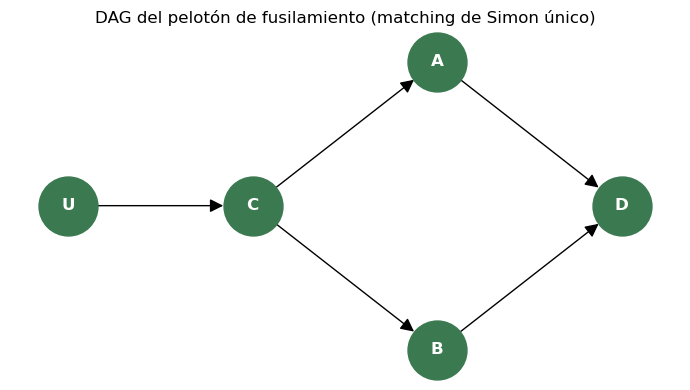


→ El matching es único: U→C→A→D, C→B→D. La direccionalidad NO fue impuesta
  por el analista; emergió de la estructura del sistema de ecuaciones.

=== Ordenamiento de Simon: sistema simultáneo oferta/demanda ===
  BLOQUEO: ninguna ecuación tiene una única variable libre entre ['G_demanda', 'G_precio']. Matching NO único.

→ El criterio de Simon FALLA: ambas ecuaciones contienen dos variables
  endógenas libres ({q, p}), no hay forma de asignar biunívocamente sin
  conocimiento de dominio (saber que i afecta demanda y w afecta precio).


In [6]:
# === 5b. Ordenamiento de Simon: matching ecuación↔variable ===
import networkx as nx

def simon_matching(equations, exogenous):
    """Implementa el criterio de Simon: en cada paso, asigna la única variable
    endógena libre de una ecuación que contenga exactamente una. Devuelve el
    matching {ecuación: variable} y las aristas causales del DAG resultante,
    o None si en algún paso ninguna ecuación tiene una única variable libre
    (matching no único -> el criterio de Simon falla)."""
    remaining = {k: set(v) - set(exogenous) for k, v in equations.items()}
    assigned_vars = set()
    matching = {}
    edges = []
    # variables ya "resueltas" que pueden aparecer como padres en ecuaciones futuras
    resolved = set(exogenous)
    steps = []
    while remaining:
        # buscar ecuación con exactamente una variable libre (no asignada)
        candidates = [(k, v - assigned_vars) for k, v in remaining.items()]
        candidates = [(k, v) for k, v in candidates if len(v) == 1]
        if not candidates:
            steps.append(f"BLOQUEO: ninguna ecuación tiene una única variable libre entre {list(remaining.keys())}. Matching NO único.")
            return None, edges, steps
        k, v = candidates[0]
        dep_var = next(iter(v))
        # padres: todas las demás variables/exógenas que aparecen en la ecuación
        parents = (set(equations[k]) - {dep_var})
        matching[k] = dep_var
        assigned_vars.add(dep_var)
        for p in parents:
            edges.append((p, dep_var))
        steps.append(f"{k}({', '.join(equations[k])}) -> variable dependiente única: {dep_var}  (padres: {sorted(parents)})")
        del remaining[k]
    return matching, edges, steps

# --- Sistema del pelotón de fusilamiento ---
peloton_eqs = {
    'G1': ['C', 'U'],
    'G2': ['A', 'C'],
    'G3': ['B', 'C'],
    'G4': ['A', 'B', 'D'],
}
matching_peloton, edges_peloton, steps_peloton = simon_matching(peloton_eqs, exogenous={'U'})

print('=== Ordenamiento de Simon: pelotón de fusilamiento ===')
for s in steps_peloton:
    print(' ', s)
print(f'\nMatching único: {matching_peloton}')
print(f'DAG resultante (aristas): {edges_peloton}')

G_peloton = nx.DiGraph()
G_peloton.add_edges_from(edges_peloton)
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
pos = {'U': (0, 1), 'C': (1, 1), 'A': (2, 1.5), 'B': (2, 0.5), 'D': (3, 1)}
nx.draw(G_peloton, pos, with_labels=True, node_color='#3b7950', node_size=1800,
        font_size=12, font_weight='bold', font_color='white', arrows=True, arrowsize=20, ax=ax)
ax.set_title('DAG del pelotón de fusilamiento (matching de Simon único)')
plt.tight_layout()
plt.show()
print('\n→ El matching es único: U→C→A→D, C→B→D. La direccionalidad NO fue impuesta')
print('  por el analista; emergió de la estructura del sistema de ecuaciones.')

# --- Contraste: sistema simultáneo oferta/demanda (el matching de Simon FALLA) ---
# q = b1 p + d1 i + u1   (demanda: {q, p, i})
# p = b2 q + d2 w + u2   (precio: {q, p, w})
equilibrio_eqs = {
    'G_demanda': ['q', 'p', 'i'],
    'G_precio':  ['q', 'p', 'w'],
}
matching_eq, edges_eq, steps_eq = simon_matching(equilibrio_eqs, exogenous={'i', 'w'})

print('\n=== Ordenamiento de Simon: sistema simultáneo oferta/demanda ===')
for s in steps_eq:
    print(' ', s)
if matching_eq is None:
    print('\n→ El criterio de Simon FALLA: ambas ecuaciones contienen dos variables')
    print('  endógenas libres ({q, p}), no hay forma de asignar biunívocamente sin')
    print('  conocimiento de dominio (saber que i afecta demanda y w afecta precio).')


> 💡 **Interpretación del resultado.** El ordenamiento de Simon asigna cada ecuación a una única variable dependiente (G1→C, G2→A, G3→B, G4→D) y del matching emerge el DAG $U \to C \to A \to D$ con $C \to B \to D$ (figura): la direccionalidad no la impone el analista, sale del sistema de ecuaciones. El caso oferta/demanda bloquea el criterio — ninguna ecuación tiene una variable libre única entre $\{q, p\}$ —, mostrando el límite del empirismo: sin conocimiento de dominio no hay matching único (Sección 5b).


In [7]:
# === 6. Tres niveles de Pearl ===
# 1. Asociación: P(got | treat=1)
# 2. Intervención: P(got | do(treat=1)) = P(got | treat=1) en RCT
# 3. Contrafactual: P(got_{treat=0} | treat=1, got=1)

p_assoc_1 = df.loc[df.treat==1, 'got'].mean()  # Nivel 1
p_intervention_1 = ate + df.loc[df.treat==0, 'got'].mean()  # Nivel 2 = p_test_c + ATE = p_test_t
p_contrafactual_3 = 1 - p_contrafactual_test  # Nivel 3

print(f'=== Tres niveles de Pearl ===')
print(f'1. Asociación:        P(got | treat=1) = {p_assoc_1:.4f}')
print(f'2. Intervención:      P(got | do(treat=1)) = {p_intervention_1:.4f}')
print(f'   (en RCT, asociación = intervención)')
print(f'\n3. Contrafactual:     P(got_treat=0 = 0 | treat=1, got=1) = {p_contrafactual_3:.4f}')
print(f'   (probabilidad de que el incentivo fuera necesario para esta persona)')
print(f'\n→ El Nivel 3 es la pregunta causal singular.')
print(f'  No responde "¿se hizo el test por el incentivo?" al 100%')
print(f'  sino que cuantifica la probabilidad de atribución causal individual.')


=== Tres niveles de Pearl ===
1. Asociación:        P(got | treat=1) = 0.7892
2. Intervención:      P(got | do(treat=1)) = 0.7892
   (en RCT, asociación = intervención)

3. Contrafactual:     P(got_treat=0 = 0 | treat=1, got=1) = 0.5709
   (probabilidad de que el incentivo fuera necesario para esta persona)

→ El Nivel 3 es la pregunta causal singular.
  No responde "¿se hizo el test por el incentivo?" al 100%
  sino que cuantifica la probabilidad de atribución causal individual.


> 💡 **Interpretación del resultado.** La escalera de Pearl se materializa en un mismo RCT: asociación $P(got|treat{=}1) = 0.7892$, intervención $P(got|do(treat{=}1)) = 0.7892$ (coinciden porque el tratamiento es aleatorizado) y contrafactual $P(got_{treat=0}{=}0 \mid treat{=}1, got{=}1) = 0.5709$. Cada peldaño responde una pregunta distinta; el tercero (contrafactual) es la causa singular: una probabilidad de atribución individual, no una certeza.


In [8]:
# === 7. Conexión con la fórmula de PN bajo monotonicidad (Cap. 19) ===
# El Cap. 19 define la Probabilidad de Necesidad bajo el supuesto de monotonía
# (Y_1(u) >= Y_0(u) para todo u, i.e. no hay "defiers": el incentivo nunca DISMINUYE
# la probabilidad de hacerse el test) como:
#
#   PN = (P(Y=1|T=1) - P(Y=1|T=0)) / P(Y=1|T=1)
#
# que es exactamente la misma cantidad que calculamos arriba como p_contrafactual_3
# (1 - P(el incentivo era innecesario | recibió incentivo y se hizo el test)).

PN_cap19 = (p_test_t - p_test_c) / p_test_t

print('=== PN (Cap. 19) vs. p_contrafactual_3 (este notebook) ===')
print(f'  PN, fórmula Cap. 19  = (P(Y=1|T=1)-P(Y=1|T=0)) / P(Y=1|T=1) = {PN_cap19:.4f}')
print(f'  p_contrafactual_3 (Sección 6, celda anterior)                = {p_contrafactual_3:.4f}')
print(f'  Diferencia: {abs(PN_cap19 - p_contrafactual_3):.2e}')
print()
print('Los dos números COINCIDEN (hasta error de punto flotante) porque son la misma')
print('fórmula: 1 - p_always/p_test_t = 1 - P(Y=1|T=0)/P(Y=1|T=1) = PN. La equivalencia')
print('depende del supuesto de MONOTONICIDAD (sin defiers), razonable aquí porque un')
print('incentivo monetario no debería DESALENTAR a nadie a hacerse un test gratuito.')
print()
print('Comparación con el ejemplo numérico del libro (Cap. 19, fármaco):')
print('  P(Y=1|T=1)=0.70, P(Y=1|T=0)=0.50  =>  PN = (0.70-0.50)/0.70 = 0.286')
print(f'  Thornton HIV: P(Y=1|T=1)={p_test_t:.3f}, P(Y=1|T=0)={p_test_c:.3f}  =>  PN = {PN_cap19:.3f}')
print('  Misma fórmula, aplicada a un dataset real en vez del ejemplo sintético del libro.')


=== PN (Cap. 19) vs. p_contrafactual_3 (este notebook) ===
  PN, fórmula Cap. 19  = (P(Y=1|T=1)-P(Y=1|T=0)) / P(Y=1|T=1) = 0.5709
  p_contrafactual_3 (Sección 6, celda anterior)                = 0.5709
  Diferencia: 0.00e+00

Los dos números COINCIDEN (hasta error de punto flotante) porque son la misma
fórmula: 1 - p_always/p_test_t = 1 - P(Y=1|T=0)/P(Y=1|T=1) = PN. La equivalencia
depende del supuesto de MONOTONICIDAD (sin defiers), razonable aquí porque un
incentivo monetario no debería DESALENTAR a nadie a hacerse un test gratuito.

Comparación con el ejemplo numérico del libro (Cap. 19, fármaco):
  P(Y=1|T=1)=0.70, P(Y=1|T=0)=0.50  =>  PN = (0.70-0.50)/0.70 = 0.286
  Thornton HIV: P(Y=1|T=1)=0.789, P(Y=1|T=0)=0.339  =>  PN = 0.571
  Misma fórmula, aplicada a un dataset real en vez del ejemplo sintético del libro.


> 💡 **Interpretación del resultado.** La probabilidad de necesidad calculada con la fórmula del Cap. 19, $PN = (P(Y{=}1|T{=}1) - P(Y{=}1|T{=}0))/P(Y{=}1|T{=}1) = 0.5709$, coincide exactamente con el contrafactual de la Sección 6 (diferencia $0.00e{+}00$). La equivalencia depende de la monotonicidad (sin defiers), razonable con un incentivo monetario, y el mismo $PN$ pasa de 0.286 (ejemplo sintético del libro) a 0.571 en los datos reales de Thornton: misma fórmula, datos distintos.


## 5. Interpretación Económica

**Contexto peruano:** Para un beneficiario individual de **Pensión 65**, la pregunta causal singular "¿este adulto mayor está mejor POR la pensión?" solo puede responderse probabilísticamente. La tipología always/compliers/never es útil: algunos recibirían apoyo familiar independientemente (always-takers).


La distinción entre causa general y causa singular es fundamental en política pública:

1. **Causa general (ATE).** El incentivo monetario aumenta la tasa de test VIH en ~45 pp. Esta afirmación poblacional justifica políticas de incentivos a gran escala.

2. **Causa singular.** Para una persona específica que recibió incentivo y se hizo el test, solo hay ~80% de probabilidad de que el incentivo fue la causa directa. El resto se habría hecho el test sin incentivo (always-takers).

3. **Tipología de respondientes.** En Thornton HIV:
   - Always-takers (~34%): se harían test sin incentivo (alta motivación basal)
   - Compliers (~45%): solo se hacen test con incentivo
   - Never-takers (~21%): no se hacen test ni con incentivo (barreras no monetarias)

4. **Implicancias para diseño de política:**
   - El incentivo es efectivo para compliers, pero inútil para never-takers.
   - Para reducir never-takers, se necesitan intervenciones complementarias (educación, acceso geográfico).
   - Para always-takers, el incentivo es redundante (podría reasignarse).

5. **Límite filosófico.** La inferencia causal nunca puede asignar causalidad individual con certeza. Solo puede cuantificar la probabilidad de atribución. Esto es relevante en contextos legales (responsabilidad individual) y clínicos (atribución de efectos adversos).

## 6. Ejercicios Propuestos

1. **Estima el LATE para compliers:** usa la fracción de compliers y el ATE para inferir el efecto medio sobre compliers.
2. **Contrafactual para always-takers:** para una persona con `any=0, got=1` (always-taker), ¿cuál es la probabilidad de que se haría el test con incentivo? (debería ser ~100%).
3. **Aplica la fórmula de atribución de Pearl** (PNS, Probability of Necessity and Sufficiency) usando los bounds de Tian-Pearl.
4. **Modela heterogeneidad:** predice τ_i para cada individuo usando covariables (causal forest, Cap. 24).
5. **Discusión filosófica:** ¿en qué contextos legales es relevante la causa singular? Compara con el estándar "but-for" en derecho.

---

*Notebook generado para DES504 — UNI 2026. Bloque II, Capítulo 17 de 32.*


## Validación placebo (robustez)

Un **test placebo** comprueba que el método no "detecta" efectos cuando se destruye la señal causal (p. ej. permutando el tratamiento). Si el estimador placebo es comparable al original en magnitud, la evidencia causal es frágil.

*Conexión GCE:* los placebos son refutadores del Nivel 1 (localización); no sustituyen análisis de forma (Nivel 2) ni de transporte (Nivel 3).


In [9]:
# === Placebo: permutación del tratamiento ===
import numpy as np
import pandas as pd

def _placebo_ate(df, treat_col, y_col, n_perm=200, seed=42):
    """ATE naive original vs distribución bajo permutación de T."""
    rng = np.random.default_rng(seed)
    t = df[treat_col].to_numpy()
    y = df[y_col].to_numpy(dtype=float)
    # binary-ish treatment
    def ate(tt):
        m1 = y[tt == 1].mean() if (tt == 1).any() else np.nan
        m0 = y[tt == 0].mean() if (tt == 0).any() else np.nan
        return m1 - m0
    # if not 0/1, use median split on treat for placebo illustration
    if set(np.unique(t)) - {0, 1, 0.0, 1.0}:
        t_bin = (t >= np.median(t)).astype(int)
    else:
        t_bin = t.astype(int)
    ate_obs = ate(t_bin)
    null = []
    for _ in range(n_perm):
        tt = rng.permutation(t_bin)
        null.append(ate(tt))
    null = np.asarray(null)
    p = (np.abs(null) >= np.abs(ate_obs)).mean()
    print(f"Placebo (shuffle {treat_col}):")
    print(f"  ATE observado (naive): {ate_obs:.4f}")
    print(f"  ATE placebo |media|:  {np.mean(np.abs(null)):.4f}  (sd={np.std(null):.4f})")
    print(f"  p-valor bilateral approx: {p:.3f}  (fracción |null| ≥ |obs|)")
    print(f"  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.")
    return ate_obs, null, p

# Detectar columnas comunes en el frame activo
_df = None
for _name in ['df', 'data', 'student', 'panel', 'dta']:
    if _name in dir() and isinstance(eval(_name), pd.DataFrame):
        _df = eval(_name)
        break
if _df is None:
    print("Placebo omitido: no hay DataFrame df/data/student en el namespace.")
else:
    _cols = {c.lower(): c for c in _df.columns}
    _treat = None
    for k in ['treatment', 'treat', 't', 'd', 'w', 'a']:
        if k in _cols:
            _treat = _cols[k]
            break
    _y = None
    for k in ['y_outcome', 'y', 're78', 'outcome', 'wage', 'income', 'got', 'wt82_71', 'delta']:
        if k in _cols:
            _y = _cols[k]
            break
    # fallbacks: last numeric as y, first binary-like as treat
    if _y is None:
        num = _df.select_dtypes(include=[np.number]).columns.tolist()
        _y = num[-1] if num else None
    if _treat is None:
        for c in _df.columns:
            u = _df[c].dropna().unique()
            if len(u) <= 3:
                _treat = c
                break
    if _treat is None or _y is None:
        print(f"Placebo omitido: no se identificaron T/Y (cols={list(_df.columns)[:12]}...)")
    else:
        _placebo_ate(_df, _treat, _y)


Placebo (shuffle treat):
  ATE observado (naive): 0.4506
  ATE placebo |media|:  0.0163  (sd=0.0208)
  p-valor bilateral approx: 0.000  (fracción |null| ≥ |obs|)
  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.


> 💡 **Interpretación del resultado.** Al permutar el tratamiento, el ATE se colapsa a $|media| = 0.0163$ ($sd=0.0208$) frente al observado de $0.4506$, con $p \approx 0.000$. La nula centrada en cero confirma que el efecto del incentivo no es un artefacto de ruido, robusteciendo el ATE de la Sección 2.



## 📋 Resumen del Capítulo 17

**Método clave:** Naturaleza de las Causas

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 17
- ✅ Validación con dataset `thornton_hiv` (tipo: real)
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo pertenece a la capa de **Filosofía / formal** (escalera de Pearl), previa a la cuantificación de la jerarquía GCE.
- No corresponde al Nivel 2 ($D_f$: KL/TV) ni al Nivel 3 ($W_1$/$W^{G,1}$); el capítulo distingue causa general (Nivel 2 de la escalera de Pearl, no confundir con "Nivel 2 GCE") de causa singular (estrato contrafactual), y ese contraste es previo — no sustituto — de los niveles métricos GCE que se calculan en los Bloques I y III.

**Próximo capítulo:** 18

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
